In [6]:
import os
import time
import random
import cv2

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras import models, Sequential, layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger,
    ReduceLROnPlateau
)

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles

from tensorflow.keras.optimizers import AdamW

In [7]:
import torch
torch.cuda.is_available()

AttributeError: partially initialized module 'torch' has no attribute 'version' (most likely due to a circular import)

### FACE LANDMARKER

In [ ]:
'''
BASE_OPTIONS - is to specify model path
OPTIONS - is to specify:
 - output_face_blendshapes (True to get blendshapes)
 - output_facial_transformation_matrixes(True to get transformation matrixes)
 - num_faces(1 to detect one face)
DETECTOR - is to create face landmarker object to detect face landmarks
'''
BASE_OPTIONS = python.BaseOptions(model_asset_path='../face_landmarker_v2_with_blendshapes.task')
OPTIONS = vision.FaceLandmarkerOptions(base_options=BASE_OPTIONS,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
DETECTOR = vision.FaceLandmarker.create_from_options(OPTIONS)


TRAIN_DATA_PATH = "../affectnet_dataset/Train"
TEST_DATA_PATH = "../affectnet_dataset/Test"
ORIGINAL_DATA_PATH = "../affectnet_dataset"
# CLAHE_DATASET_PATH = "../clahe_dataset"
# MASK_DATASET_PATH = "../mask_dataset"

EPOCHS = 100
RANDOM_SEED = 40
BATCH_SIZE = 32
IMG_SIZE = (96,96)
SAVED_MODEL = "../saved_models/mlp_model.h5"

In [ ]:
os.environ["PYTHONHASHSEED"] = str(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

In [ ]:
KEYPOINTS_DIR = "../affectnet_keypoints"
# keypoints_clahe_dir = "../clahe_keypoints"
# keypoints_mask_dir = "../mask_keypoints"

os.makedirs(KEYPOINTS_DIR, exist_ok=True)
# os.makedirs(keypoints_clahe_dir, exist_ok=True)
# os.makedirs(keypoints_mask_dir, exist_ok=True)

DATA_DIRS = {
    "train": TRAIN_DATA_PATH,
    "test": TEST_DATA_PATH
}
# data_dirs = {
#     "train": os.path.join(CLAHE_DATASET_PATH, "Train"),
#     "test": os.path.join(CLAHE_DATASET_PATH, "Test")
# }
# data_dirs = {
#     "train": os.path.join(MASK_DATASET_PATH, "Train"),
#     "test": os.path.join(MASK_DATASET_PATH, "Test")
# }

In [5]:
# # Loop through the dataset directories and extract keypoints for each image
# for split, split_dir in data_dirs.items():
#     LANDMARKS = 478
#     for class_name in sorted(os.listdir(split_dir)):
#         class_path = os.path.join(split_dir, class_name)
#         if not os.path.isdir(class_path):
#             continue

#         save_class_path = os.path.join(keypoints_dir, split, class_name)
#         os.makedirs(save_class_path, exist_ok=True)

#         for img_name in os.listdir(class_path):
#             if img_name.startswith("."):
#                 continue

#             img_path = os.path.join(class_path, img_name)

#             img = cv2.imread(img_path)
#             if img is None:
#                 continue

#             img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#             img = cv2.resize(img,IMG_SIZE)

#             mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img)

#             results = detector.detect(mp_image)

#             if results.face_landmarks:
#                 face_landmarks = results.face_landmarks[0]
#                 if (len(face_landmarks) == LANDMARKS):
#                     keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
#                 else:
#                     continue
#             else:
#                continue

#             save_path = os.path.join(
#                 save_class_path,
#                 img_name.split('.')[0] + ".npy"
#             )
#             np.save(save_path, keypoints)

# print("Keypoints saved in folder:", keypoints_dir)

In [ ]:
# check if kp saved correctly (should be 478 kp, 3 coordinates[x,y,z])
folder = "../affectnet_keypoints/train/contempt"
# folder = "../clahe_keypoints/train/contempt"
# folder = "../mask_keypoints/train/contempt"

# List all .npy files
files = [f for f in os.listdir(folder) if f.endswith(".npy")]

first_img = os.path.join(folder, files[0])
keypoints = np.load(first_img)
print(keypoints.shape)

NameError: name 'os' is not defined

In [ ]:
# Load keypoints arrays
def load_keypoints_dataset(base_dir):
    X, y = [], []
    for class_name in sorted(os.listdir(base_dir)):
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        for file in os.listdir(class_path):
            if not file.endswith(".npy"):
                continue
            keypoints = np.load(os.path.join(class_path, file))
            X.append(keypoints)
            y.append(class_name)
    return np.array(X), np.array(y)

X, y = load_keypoints_dataset("../affectnet_keypoints/train")
# X, y = load_keypoints_dataset("../clahe_keypoints/train")
# X, y = load_keypoints_dataset("../mask_keypoints/train")

In [8]:
print(y[:5])

['anger' 'anger' 'anger' 'anger' 'anger']


In [ ]:
'''
LabelEncoder() - to convert string lbl to int
to_categorical() - to convert int lbl to one-hot encoding
reshape - to convert 3D array (samples, landmarks, coordinates) 
to 2D array (samples, features), because MLP expects 2D input (samples, features)

StandardScaler() - to standardize features by removing the mean and scaling to unit variance
(data is scaled to have a standard deviation of 1)
'''
le = LabelEncoder()
y = le.fit_transform(y) # to convert string labels to integers
# y = to_categorical(y) 


# Split FIRST
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y # to keep class distribution in train/val splits
)

X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)

# THEN standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
print(X_train.shape, y_train.shape)

# (12830, 1434) (12830, 8)
# number of samples - 12830
# number of features per sample - 1434 (478 features * 3 x,y,z coordinates)

(12862, 1434) (12862,)


In [10]:
print(y[:5])

[0 0 0 0 0]


In [11]:
y[3400:3410]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
'''
apply a weight to each class based on its frequency
class weights given based on the formula:
n_samples / (n_classes * np.bincount(y))
- np.bincount(y) counts number of occurrences of each class in train lbl.
'''

num_classes = len(np.unique(y))
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_train
)
weights = dict(enumerate(class_weights_array))
print("Class weights array:", weights)

Class weights array: {np.int64(0): np.float64(1.336450540315877), np.int64(1): np.float64(1.2934432823813355), np.int64(2): np.float64(1.5981610337972167), np.int64(3): np.float64(1.315671031096563), np.int64(4): np.float64(0.8709371614301191), np.int64(5): np.float64(0.7271596562641339), np.int64(6): np.float64(0.6575664621676892), np.int64(7): np.float64(0.9535883748517201)}


In [13]:
model = tf.keras.Sequential([
    layers.Input(shape=(1434,)),
    
    # Block 1
    layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.4),

    # Block 2
    layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.3),

    # Block 3
    layers.Dense(128, kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.2),

    layers.Dense(8, activation='softmax')
])

model.compile(optimizer=AdamW(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       734,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 903,560 (3.45 MB)

 Trainable params: 901,768 (3.44 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)
mc = ModelCheckpoint(
    SAVED_MODEL,
    monitor='val_loss',
    save_best_only=True
)
rlr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3, #0.5
    patience=3,    
    min_lr=1e-6
)
csv_logger = CSVLogger('../logs/mlp_weighted_loss_training_log.csv')

In [ ]:
start = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=weights,
    callbacks=[es, mc, csv_logger,rlr]
)
end = time.time()
elapsed_time = end - start

print("Training time: ", time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))

Epoch 1/100
401/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3560 - loss: 1.8522

402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4016 - loss: 1.6976 - val_accuracy: 0.5171 - val_loss: 1.3593 - learning_rate: 0.0010
Epoch 2/100
397/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4474 - loss: 1.5444

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4584 - loss: 1.5144 - val_accuracy: 0.5162 - val_loss: 1.3021 - learning_rate: 0.0010
Epoch 3/100
392/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4887 - loss: 1.4451

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4985 - loss: 1.4320 - val_accuracy: 0.5233 - val_loss: 1.2750 - learning_rate: 0.0010
Epoch 4/100
396/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5040 - loss: 1.4159

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5071 - loss: 1.4073 - val_accuracy: 0.5432 - val_loss: 1.2542 - learning_rate: 0.0010
Epoch 5/100
392/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5148 - loss: 1.3818

...

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6393 - loss: 1.0747 - val_accuracy: 0.6418 - val_loss: 1.0148 - learning_rate: 2.4300e-06
Epoch 43/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6378 - loss: 1.0804 - val_accuracy: 0.6409 - val_loss: 1.0151 - learning_rate: 2.4300e-06
Epoch 44/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6365 - loss: 1.0868

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6362 - loss: 1.0842 - val_accuracy: 0.6430 - val_loss: 1.0135 - learning_rate: 2.4300e-06
Epoch 45/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6337 - loss: 1.0832 - val_accuracy: 0.6405 - val_loss: 1.0154 - learning_rate: 2.4300e-06
Epoch 46/100
391/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6327 - loss: 1.0873

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6358 - loss: 1.0851 - val_accuracy: 0.6415 - val_loss: 1.0131 - learning_rate: 2.4300e-06
Epoch 47/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6367 - loss: 1.0839 - val_accuracy: 0.6421 - val_loss: 1.0137 - learning_rate: 2.4300e-06
Epoch 48/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6371 - loss: 1.0829 - val_accuracy: 0.6424 - val_loss: 1.0137 - learning_rate: 2.4300e-06
Epoch 49/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6370 - loss: 1.0789

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6378 - loss: 1.0897 - val_accuracy: 0.6424 - val_loss: 1.0126 - learning_rate: 2.4300e-06
Epoch 50/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6345 - loss: 1.0752 - val_accuracy: 0.6387 - val_loss: 1.0151 - learning_rate: 2.4300e-06
Epoch 51/100
394/402 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6422 - loss: 1.0736

402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6381 - loss: 1.0837 - val_accuracy: 0.6443 - val_loss: 1.0119 - learning_rate: 2.4300e-06
Epoch 52/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6322 - loss: 1.0860 - val_accuracy: 0.6405 - val_loss: 1.0140 - learning_rate: 2.4300e-06
Epoch 53/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6344 - loss: 1.0773 - val_accuracy: 0.6393 - val_loss: 1.0145 - learning_rate: 2.4300e-06
Epoch 54/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6385 - loss: 1.0835 - val_accuracy: 0.6412 - val_loss: 1.0136 - learning_rate: 2.4300e-06
Epoch 55/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6361 - loss: 1.0775 - val_accuracy: 0.6430 - val_loss: 1.0129 - learning_rate: 1.0000e-06
Epoch 56/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6334 - loss: 1.0787 - val_accuracy: 0.6418 - val_loss: 1.0126 - learning_rate: 1.0000e-06
Epoch 57/100
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy:

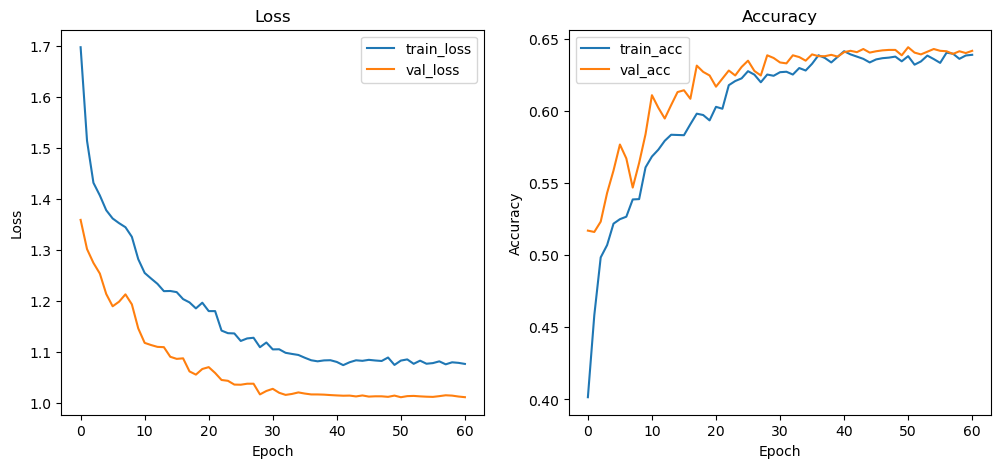

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
model = models.load_model(SAVED_MODEL)

In [18]:
# load test data
X_test, y_test = load_keypoints_dataset("../affectnet_keypoints/test")
# X_test, y_test = load_keypoints_dataset("../clahe_keypoints/test")
# X_test, y_test = load_keypoints_dataset("../mask_keypoints/test")

X_test = X_test.reshape(X_test.shape[0], -1)
# Encode labels using  same LabelEncoder as training
# `le` is label encoder fitted on training labels
y_test_enc = le.transform(y_test) 
# y_test_cat = to_categorical(y_test_enc)  # one-hot

# scaler is the StandardScaler fitted on training data
# scalar.transform() standardizes test features using training mean and std
X_test = scaler.transform(X_test)

print("X_test shape:", X_test.shape)
print("y_test_enc shape:", y_test_enc.shape)

X_test shape: (14480, 1434)
y_test_enc shape: (14480,)


In [19]:
# Predict probabilities
yhat_probs = model.predict(X_test)  # shape (num_samples, 8)

# Convert probabilities to predicted class indices
yhat = np.argmax(yhat_probs, axis=1)

# True class indices
ytrue = y_test_enc

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
def evaluate(model, X_test, y_test_enc, class_names):
    print("Evaluating on test set...")
    test_loss, test_acc = model.evaluate(X_test, y_test_enc, verbose=1)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    print("\nGenerating predictions...")
    y_prob = model.predict(X_test, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    macro_f1 = f1_score(y_test_enc, y_pred, average="macro")
    print(f"\nMacro F1: {macro_f1:.4f}")

    print("\nClassification Report:\n")
    print(classification_report(
        y_test_enc,
        y_pred,
        target_names=class_names,
        zero_division=0
    ))

    cm_norm = confusion_matrix(
        y_test_enc,
        y_pred,
        labels=np.arange(len(class_names)),
        normalize="true"
    )

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Normalized Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return test_loss, test_acc, macro_f1, cm_norm

evaluate(model, X_test, y_test_enc, le.classes_)

NameError: name 'y_test_cat' is not defined

In [ ]:
def predict_images_with_keypoints(image_dir, model, scaler, le, n=5):
    images_paths = []

    # collect all images
    for class_name in os.listdir(image_dir):
        class_path = os.path.join(image_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        for img_name in os.listdir(class_path):
            if img_name.startswith("."):
                continue
            images_paths.append((os.path.join(class_path, img_name), class_name))

    # pick random samples
    samples = np.random.choice(len(images_paths), n, replace=False)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))

    for i, idx in enumerate(samples):
        img_path, true_label = images_paths[idx]

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # --- KEYPOINT EXTRACTION ---
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        results = DETECTOR.detect(mp_image)

        if not results.face_landmarks:
            pred_label = "No face"
            confidence = 0
        else:
            face_landmarks = results.face_landmarks[0]

            keypoints = np.array([[lm.x, lm.y, lm.z] for lm in face_landmarks])
            keypoints = keypoints.reshape(1, -1)

            keypoints = scaler.transform(keypoints)

            pred_prob = model.predict(keypoints, verbose=0)[0]
            pred_idx = np.argmax(pred_prob)
            pred_label = le.classes_[pred_idx]
            confidence = pred_prob[pred_idx] * 100

        axes[i].imshow(img_rgb)
        axes[i].axis("off")

        color = "green" if pred_label == true_label else "red"

        axes[i].set_title(
            f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
            color=color
        )

    plt.tight_layout()
    plt.show()

predict_images_with_keypoints(
    "../affectnet_dataset/Test",
    model,
    scaler,
    le,
    n=5
)

In [ ]:
sample = X_test[:1]

for _ in range(10):
    model.predict(sample, verbose=0)

times=[]

for _ in range(100):
    start=time.perf_counter()

    model.predict(sample, verbose=0)

    end=time.perf_counter()

    times.append(end-start)

latency_ms=np.mean(times)*1000